In [60]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [61]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [62]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN smt.group_id is null THEN 'No Gesture' ELSE rtParent.title END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [63]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [64]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [65]:
# Augment the data in a way, that you copy all rows with their columns, only change the order of the touch_X_* columns randomly, also append a unique suffix to the id fields, group_id, session_task_id, participant_id, so that they are unique in the new dataset
def augment_data(df, n_augmentations=1):
    augmented_dfs = []
    
    for i in range(n_augmentations):
        df_aug = df.copy()
        
        # Shuffle touch columns
        shuffled_indices = np.random.permutation(5) + 1  # Touch indices from 1 to 5
        for j, new_idx in enumerate(shuffled_indices, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']
        
        # Append unique suffix to id fields
        df_aug['id'] = df_aug['id'].astype(str) + f'_aug{i}'
        df_aug['group_id'] = df_aug['group_id'].astype(str) + f'_aug{i}'
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + f'_aug{i}'
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + f'_aug{i}'
         
        augmented_dfs.append(df_aug)
    
    return pd.concat([df] + augmented_dfs, ignore_index=True)

def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))
    # randomly shuffle the permutations, in case there is a limit set
    if limit is not None:
        np.random.shuffle(permutations)

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [66]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [67]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        230485
Pinch Swipe                        12037
Tap and Hold                       11985
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [68]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [69]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [70]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [71]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

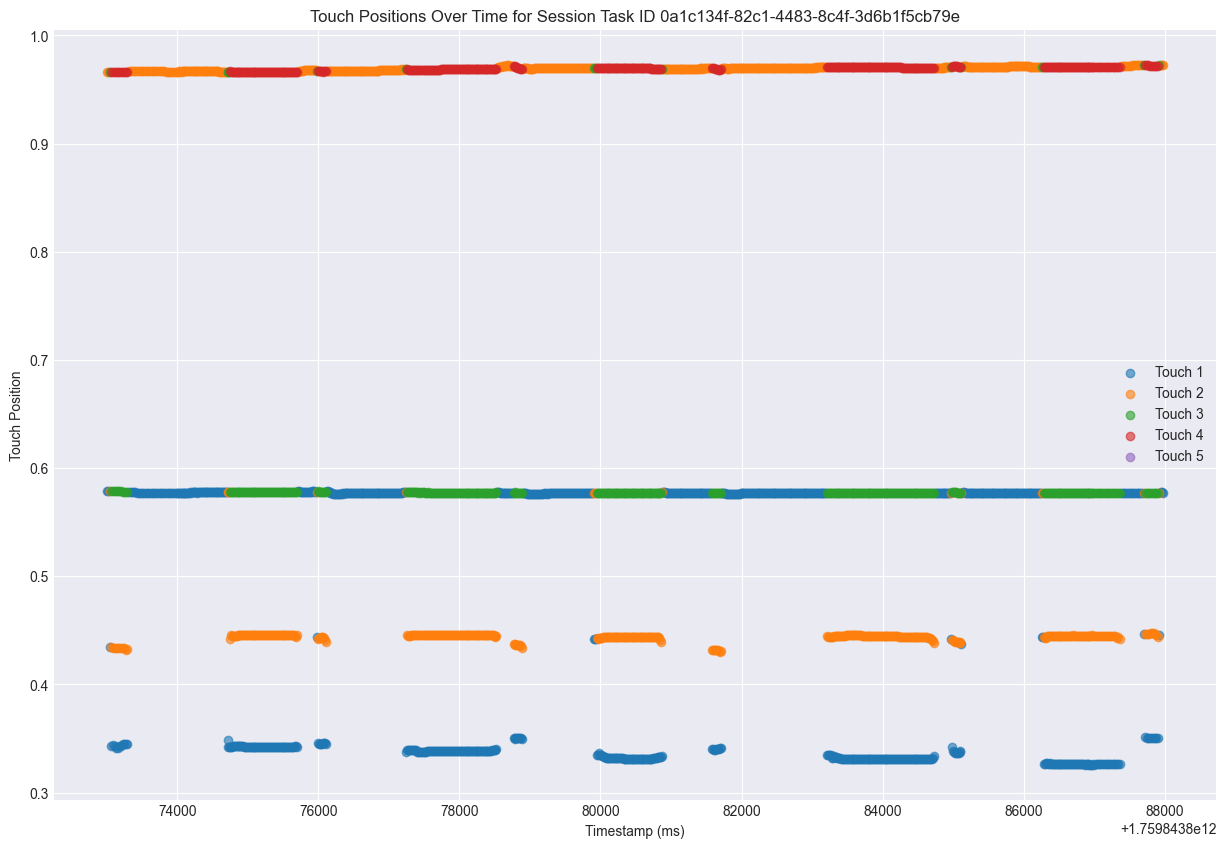

In [72]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [73]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


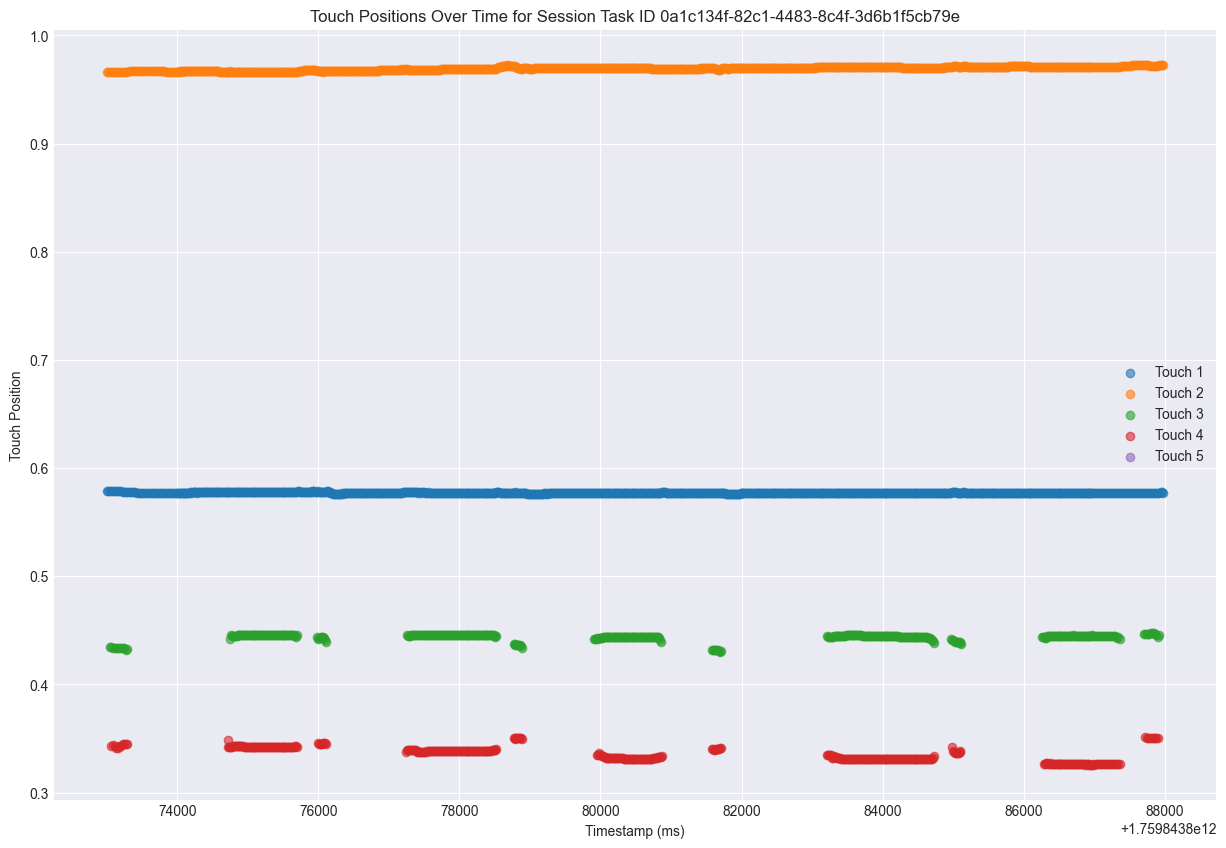

In [74]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [75]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position         0
touch_1_pressure         0
touch_1_channel          0
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            204519
dtype: int64

In [76]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

parent_gesture
No Gesture                        230485
Pinch Swipe                        12037
Tap and Hold                       11985
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64


In [77]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=20):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    # add_feature("num_active_touches", active_touches.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_touching = (p_i > 0) & (p_j > 0)
        add_feature(dist_col, dist)
        # add_feature(f"{dist_col}_both_touching", both_touching.astype(int))

        # Calculate a flag if both fingers are active in the long smoothing window
        # long_both_touching = both_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f"{dist_col}_long_both_active", long_both_touching.astype(int))

        # Calculate a flag if both have moved
        # min_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_i = (max_long_rolling_i - min_long_rolling_i) > TOUCH_MOVE_THRESHOLD
        # min_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_j = (max_long_rolling_j - min_long_rolling_j) > TOUCH_MOVE_THRESHOLD
        # both_moved = has_moved_i & has_moved_j
        # add_feature(f"{dist_col}_both_moved_longterm", both_moved.astype(int))

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        # velocity calculation
        pos_diff = feature_df[position_col].diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        velocity = pos_diff / time_diff
        # add_feature(f'touch_{touch_num}_position_velocity', velocity)

        # split to rotational position into x and y components for smoothing
        # add_feature(f'touch_{touch_num}_pos_x', np.cos(2 * np.pi * feature_df[position_col]))
        # add_feature(f'touch_{touch_num}_pos_y', np.sin(2 * np.pi * feature_df[position_col]))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for other_pos_col in other_positions:
                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col])
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other)
        # else:
        #     add_feature(f'touch_{touch_num}_min_dist_to_others', pd.Series(0, index=feature_df.index))
        #     add_feature(f'touch_{touch_num}_max_dist_to_others', pd.Series(0, index=feature_df.index))    

        is_touching = (feature_df[pressure_col] > 0)
        # add_feature(f'touch_{touch_num}_is_active', is_touching.astype(int))
        is_active_smoothed = is_touching.rolling(window=smoothing_window, min_periods=1).mean()
        # add_feature(f'touch_{touch_num}_is_active_smoothed', is_active_smoothed)

        # Add a flag, whether a finger touched and released and touched again in the smoothing window
        reactivation = (~is_touching.shift(1, fill_value=False)) & is_touching
        touch_before = is_touching.rolling(smoothing_window).max().astype(bool)
        reactivation_in_window = reactivation.rolling(smoothing_window).max().astype(bool)
        has_reactivated = (touch_before & reactivation_in_window)
        # add_feature(f'touch_{touch_num}_has_reactivated', has_reactivated.astype(int))
        # add_feature(f'touch_{touch_num}_num_reactivations', reactivation.rolling(long_smoothing_window).sum().fillna(0))

        min_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).min()
        max_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).max()
        has_moved = (max_long_rolling_pos - min_long_rolling_pos) > TOUCH_MOVE_THRESHOLD
        # add_feature(f'touch_{touch_num}_has_moved_longterm', has_moved.astype(int))

        long_touch = is_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f'touch_{touch_num}_long_touch', long_touch.astype(int))

        # Add flag if the touch is active or not, it is active if np.any(is_touching) and (has_moved or not is_continuous_touch)
        is_active_touch = is_touching & (has_moved | (~long_touch))
        # add_feature(f'touch_{touch_num}_is_active_touch', is_active_touch.astype(int))

        # Calculate time since last release (the idle gap)
        is_released = (feature_df[pressure_col] == 0)
        # Create a group that increments every time a touch starts
        touch_id = (~is_released).cumsum() 
        # Calculate time since the last 'active' period ended
        # This helps the model see how "fresh" the previous tap was
        # feature_df['time_since_release'] = feature_df.groupby(touch_id)[TIMESTAMP_COLUMN].diff()
        # add_feature(f'{touch_num}_time_since_release', feature_df['time_since_release'].fillna(0))

        # Store the position of the last touch event
        last_pos = feature_df[position_col].where(is_touching).ffill()
        # Calculate distance from the current position to where the last touch was
        dist_from_prev_tap = short_dist(feature_df[position_col], last_pos.shift(1))
        # add_feature(f'{touch_num}_dist_from_prev_tap', dist_from_prev_tap)

        # 1. Calculate the 'Rising Edge' (The moment a finger hits the glass)
        rising_edge = (feature_df[pressure_col] > 0) & (feature_df[pressure_col].shift(1) <= 0)
        lowering_edge = (feature_df[pressure_col] <= 0) & (feature_df[pressure_col].shift(1) > 0)
        any_edge = rising_edge | lowering_edge

        # 2. Count rising edges in a wider 'gesture window' (e.g., 500ms)
        # This directly tells the model: "Two taps just happened very close together"
        # add_feature(f'{touch_num}_tap_count', any_edge.rolling(window=smoothing_window, min_periods=1).sum())

        # 3. Calculate the duration of the current 'touch'
        # If this is too long, it's a 'long press', not part of a double tap
        is_touching = (feature_df[pressure_col] > 0)
        touch_duration = is_touching.groupby((is_touching != is_touching.shift()).cumsum()).cumsum()
        # add_feature(f'{touch_num}_active_duration', touch_duration * is_touching)

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    # add_feature("num_active_touches_mean", feature_df["num_active_touches"]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    # add_feature("num_active_touches_max", feature_df["num_active_touches"]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .max())
    active_touches_contrast = active_touches - active_touches.rolling(window=2, min_periods=1).median()
    # add_feature("num_active_touches_contrast", active_touches_contrast.sum(axis=1))
    
    # dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    # for col in dist_cols:
    #     add_feature(f"{col}_rollmean", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    #     add_feature(f"{col}_rollstd", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .std()
    #         .fillna(0.0))

    return feature_df, additional_features

In [78]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [79]:
df_clean = augment_data_all_permutations(df_clean, limit=20)

In [80]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = get_column_names(additional_columns)

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
prev_label = None
blocks = []
prev_group_id = None

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    lab = row[LABEL_COLUMN]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        lab != prev_label or
        group_id != prev_group_id
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_label = lab
    prev_group_id = group_id

df["gesture_block"] = blocks

In [81]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,dist_1_2,dist_1_3,dist_1_4,dist_1_5,dist_2_3,dist_2_4,dist_2_5,dist_3_4,dist_3_5,dist_4_5,touch_1_dist_to_touch_2_position,touch_1_dist_to_touch_3_position,touch_1_dist_to_touch_4_position,touch_1_dist_to_touch_5_position,touch_1_position_mean,touch_1_pressure_mean,touch_1_position_diff,touch_1_pressure_diff,touch_1_position_rollstd,touch_1_pressure_rollstd,touch_2_dist_to_touch_1_position,touch_2_dist_to_touch_3_position,touch_2_dist_to_touch_4_position,touch_2_dist_to_touch_5_position,touch_2_position_mean,touch_2_pressure_mean,touch_2_position_diff,touch_2_pressure_diff,touch_2_position_rollstd,touch_2_pressure_rollstd,touch_3_dist_to_touch_1_position,touch_3_dist_to_touch_2_position,touch_3_dist_to_touch_4_position,touch_3_dist_to_touch_5_position,touch_3_position_mean,touch_3_pressure_mean,touch_3_position_diff,touch_3_pressure_diff,touch_3_position_rollstd,touch_3_pressure_rollstd,touch_4_dist_to_touch_1_position,touch_4_dist_to_touch_2_position,touch_4_dist_to_touch_3_position,touch_4_dist_to_touch_5_position,touch_4_position_mean,touch_4_pressure_mean,touch_4_position_diff,touch_4_pressure_diff,touch_4_position_rollstd,touch_4_pressure_rollstd,touch_5_dist_to_touch_1_position,touch_5_dist_to_touch_2_position,touch_5_dist_to_touch_3_position,touch_5_dist_to_touch_4_position,touch_5_position_mean,touch_5_pressure_mean,touch_5_position_diff,touch_5_pressure_diff,touch_5_position_rollstd,touch_5_pressure_rollstd,gesture_block
0,7ae236df-3b8a-46fe-be4b-fcabf2850ad1,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,639,2025-10-07 13:31:13,1759843873000,0,0.997409,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.000000000,0.578513,0.377551,0.400000,0.966209,0.572171,0.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1]",0.387696,0.578513,0.578513,0.578513,0.966209,0.966209,0.966209,0.000000,0.000000,0.000000,0.387696,0.578513,0.578513,0.578513,0.578513,0.377551,0.000000,0.000000,0.000000,0.000000,0.387696,0.966209,0.966209,0.966209,0.966209,0.572171,0.000000,0.000000,0.000000,0.000000,0.578513,0.966209,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.578513,0.966209,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.578513,0.966209,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
1,139f6348-aacb-4142-b68b-768cbbb6f919,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,640,2025-10-07 13:31:13,1759843873022,0,0.997431,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.022727273,0.578533,0.375364,0.400000,0.966277,0.580334,0.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1]",0.387745,0.578533,0.578533,0.578533,0.966277,0.966277,0.966277,0.000000,0.000000,0.000000,0.387745,0.578533,0.578533,0.578533,0.578523,0.376458,0.000020,-0.002187,0.000014,0.001546,0.387745,0.966277,0.966277,0.966277,0.966243,0.576252,0.000069,0.008163,0.000049,0.005772,0.578533,0.966277,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.578533,0.966277,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.578533,0.966277,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,36671640-4aac-4c73-98ab-93c630992c07,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,641,2025-10-07 13:31:13,1759843873045,0,0.997425,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.045454545,0.578547,0.389239,0.333333,0.966055

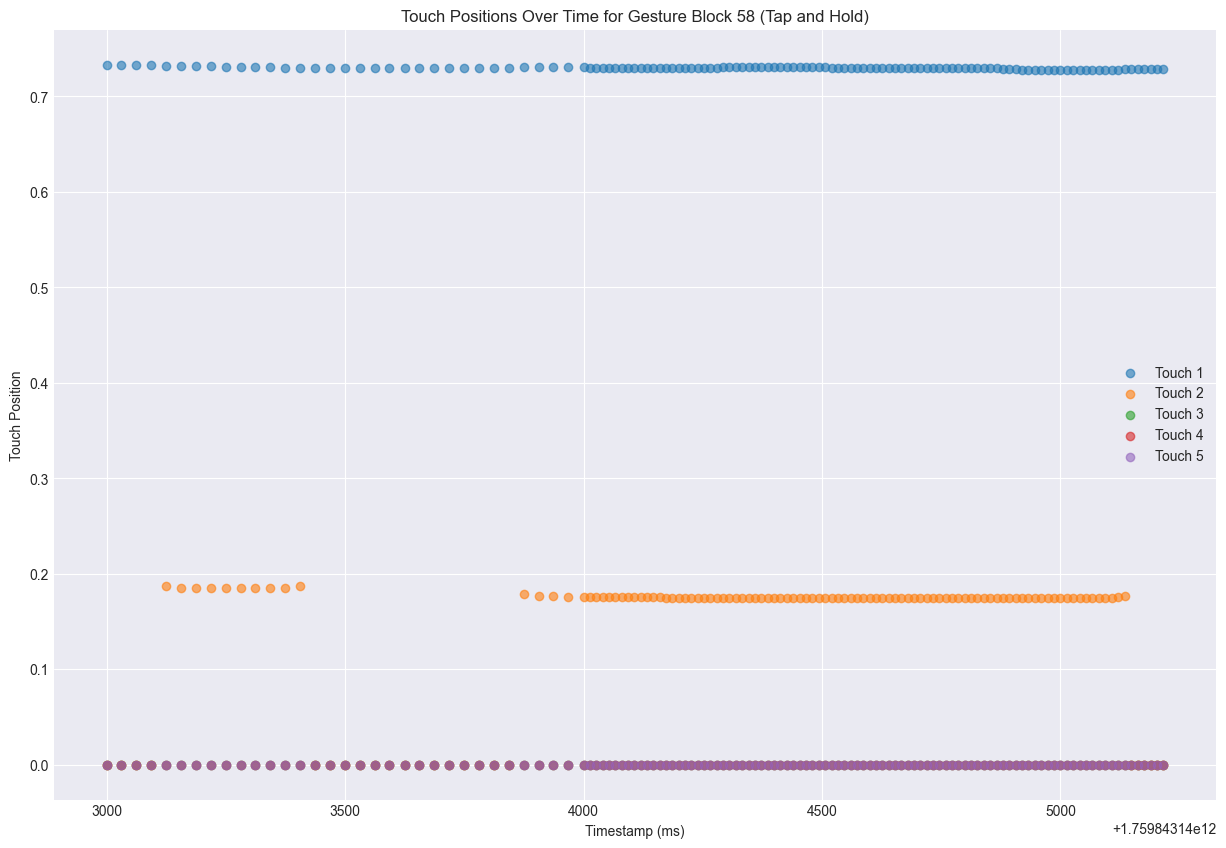

In [82]:
# draw a graph of the finger positions for the first gesture_block and title it with the parent_gesture

# get the index of the unique gesture block that is a "Tap and Hold" gesture
idx_tap_and_hold = np.where(df["gesture_block"].unique() == df[df[LABEL_COLUMN] == "Tap and Hold"]["gesture_block"].iloc[1])[0][0]

plt.figure(figsize=(15, 10))
first_gesture_block = df["gesture_block"].unique()[idx_tap_and_hold]
gesture_block_df = df[df["gesture_block"] == first_gesture_block]
for touch_num in range(1, 6):
    plt.scatter(
        gesture_block_df["timestamp_ms"], 
        gesture_block_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Gesture Block {first_gesture_block} ({gesture_block_df[LABEL_COLUMN].iloc[0]})")
plt.legend()
plt.show()

In [83]:
# Print unique "gesture" column counts
print(df["gesture"].value_counts())

gesture
Tap and Hold (3 Finger)                      480333
Pinch Swipe (Rechts)                         314160
Tap and Hold (2 Finger)                      301392
Two-Finger Tap (3 Finger)                    274512
Lay On (2 Fingers)                           272937
Two-Finger Double Tap (4 Finger)             271131
Pinch Swipe (Links)                          260757
Knob Turn (3 Fingers)                        255612
Knob Turn (All Fingers)                      250824
Lay On (3 Fingers)                           249249
Double Tap (4 Finger)                        228312
Spread Swipe (Rechts)                        215229
Two-Finger Double Tap (3 Finger)             210588
Two-Finger Opposite Double Tap (4 Finger)    204015
Single Swipe (All Air)                       203847
Spread Swipe (Links)                         195972
Two-Finger Opposite Tap (4 Finger)           192885
Single Swipe (3 Finger)                      191289
Two-Finger Tap (4 Finger)                    188979
Two-

In [84]:
gesture_blocks = (
    df[df["is_gesture"] == 1]
    .groupby(["participant_id", "session_task_id", "group_id", "gesture_block"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 20958


In [85]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, group_id, gb), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "group_id": group_id,
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "num_samples": len(X_seq),
    })

In [86]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 20958 sequences with 10 unique labels.
Label counts:
  Two-Finger Tap: 2289
  Pinch Swipe: 2163
  Double Tap: 2121
  Two-Finger Opposite Tap: 2121
  Single Tap: 2100
  Two-Finger Opposite Double Tap: 2058
  Single Swipe: 2037
  Two-Finger Double Tap: 2037
  Tap and Hold: 2016
  Spread Swipe: 2016


In [87]:
feature_columns

['dist_1_2',
 'dist_1_3',
 'dist_1_4',
 'dist_1_5',
 'dist_2_3',
 'dist_2_4',
 'dist_2_5',
 'dist_3_4',
 'dist_3_5',
 'dist_4_5',
 'touch_1_dist_to_touch_2_position',
 'touch_1_dist_to_touch_3_position',
 'touch_1_dist_to_touch_4_position',
 'touch_1_dist_to_touch_5_position',
 'touch_1_position_mean',
 'touch_1_pressure_mean',
 'touch_1_position_diff',
 'touch_1_pressure_diff',
 'touch_1_position_rollstd',
 'touch_1_pressure_rollstd',
 'touch_2_dist_to_touch_1_position',
 'touch_2_dist_to_touch_3_position',
 'touch_2_dist_to_touch_4_position',
 'touch_2_dist_to_touch_5_position',
 'touch_2_position_mean',
 'touch_2_pressure_mean',
 'touch_2_position_diff',
 'touch_2_pressure_diff',
 'touch_2_position_rollstd',
 'touch_2_pressure_rollstd',
 'touch_3_dist_to_touch_1_position',
 'touch_3_dist_to_touch_2_position',
 'touch_3_dist_to_touch_4_position',
 'touch_3_dist_to_touch_5_position',
 'touch_3_position_mean',
 'touch_3_pressure_mean',
 'touch_3_position_diff',
 'touch_3_pressure_diff'

In [88]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [89]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded


In [90]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {len(unique_participants)}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: 168
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm0', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm11', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm13', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm15', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm17', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm18', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm5', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm6', '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm8', '6331fbd1-76bb-48d6-92a2-80a55a70d134', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm1', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm10', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm11', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm12', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm13', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm14', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm15', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm17', '6331fbd1-76bb-48d6-92a2-80a55a70d134_perm18', '6331fbd1-76bb-48d6-92a2-80a55a70

In [91]:
# Split participants into train, val, test sets
train_indices = df['participant_id'].isin(train_participants)
val_indices = df['participant_id'].isin(val_participants)
test_indices = df['participant_id'].isin(test_participants)

# Map each sequence back to its participant_id
sequence_participants = []
gesture_block_keys = list(gesture_blocks.groups.keys())
for (pid, sid, grpid, gb) in gesture_block_keys:
    sequence_participants.append(pid)
sequence_participants = np.array(sequence_participants)
# Now create boolean masks for sequences
train_seq_indices = np.isin(sequence_participants, train_participants)
val_seq_indices = np.isin(sequence_participants, val_participants)
test_seq_indices = np.isin(sequence_participants, test_participants)

X_train, y_train = X[train_seq_indices], y[train_seq_indices]
X_val, y_val = X[val_seq_indices], y[val_seq_indices]
X_test, y_test = X[test_seq_indices], y[test_seq_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (12742, 406, 60), (12742, 10)
Validation set: (4107, 406, 60), (4107, 10)
Test set: (4109, 406, 60), (4109, 10)


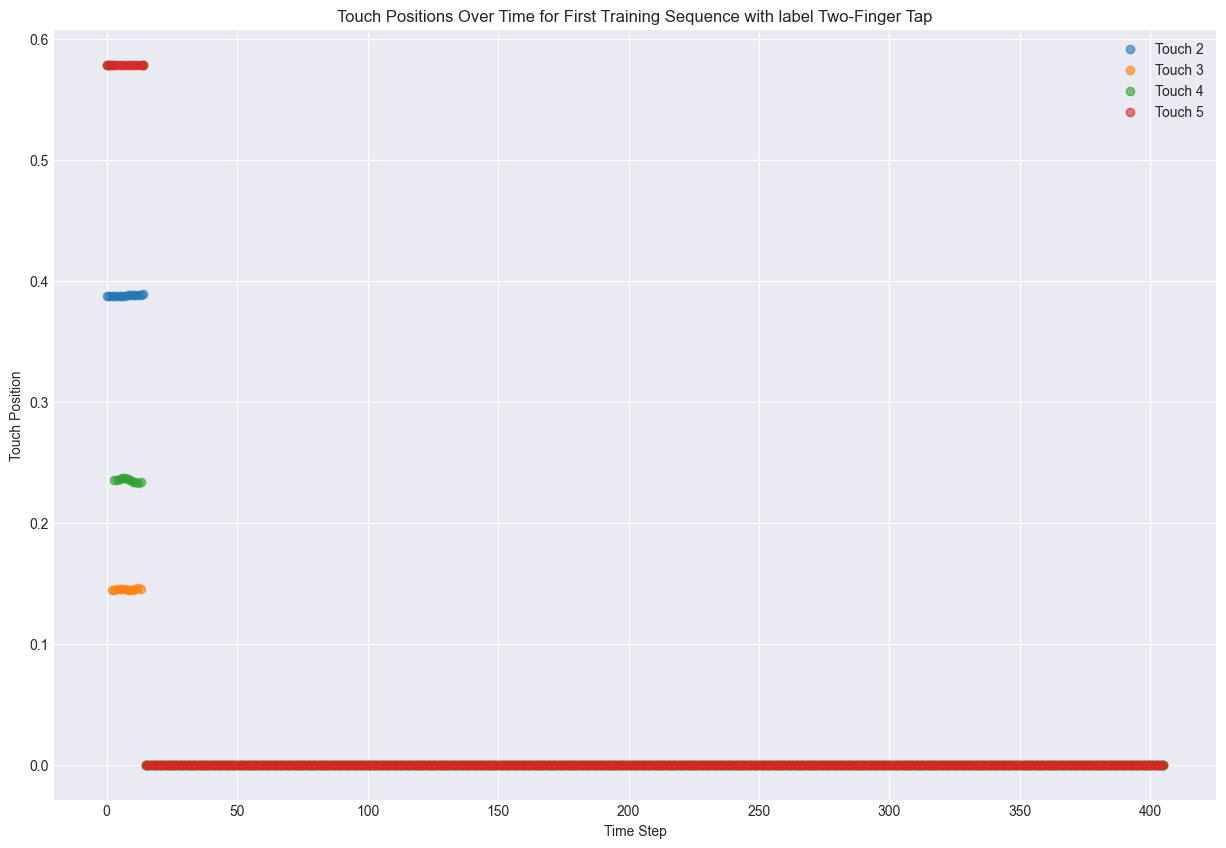

In [92]:
# Draw a graph of the first X_train sequence
plt.figure(figsize=(15, 10))
first_sequence = X_train[0]
for touch_num in range(2, 6):
    plt.scatter(
        np.arange(first_sequence.shape[0]), 
        # first_sequence[:, feature_columns.index(f"touch_{touch_num}_pos_x")], 
        # first_sequence[:, feature_columns.index(f"touch_{touch_num}_pos_y")], 
        # first_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
        first_sequence[:, feature_columns.index(f"dist_1_{touch_num}")], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Time Step")
plt.ylabel("Touch Position")
# Print label in title
plt.title(f"Touch Positions Over Time for First Training Sequence with label {le.inverse_transform([np.argmax(y_train[0])])[0]}")
plt.legend()
plt.show()

In [93]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  Double Tap: Train=1286, Val=413, Test=422
  Pinch Swipe: Train=1307, Val=418, Test=438
  Single Swipe: Train=1239, Val=400, Test=398
  Single Tap: Train=1271, Val=413, Test=416
  Spread Swipe: Train=1226, Val=396, Test=394
  Tap and Hold: Train=1220, Val=404, Test=392
  Two-Finger Double Tap: Train=1254, Val=404, Test=379
  Two-Finger Opposite Double Tap: Train=1254, Val=399, Test=405
  Two-Finger Opposite Tap: Train=1283, Val=415, Test=423
  Two-Finger Tap: Train=1402, Val=445, Test=442


In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

model = Sequential()

# 1) Masking: ignore padded timesteps (value=0.0 from preprocessing)
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation="softmax"))
optimizer = Adam(learning_rate=5e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 406, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 406, 128)       │        96,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,986 (589.79 KB)

 Trainable params: 150,986 (589.79 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 94s 116ms/step - accuracy: 0.5414 - loss: 1.1195 - val_accuracy: 0.6762 - val_loss: 0.7641
Epoch 2/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 92s 115ms/step - accuracy: 0.7522 - loss: 0.6143 - val_accuracy: 0.7938 - val_loss: 0.4952
Epoch 3/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 91s 114ms/step - accuracy: 0.8134 - loss: 0.4675 - val_accuracy: 0.8305 - val_loss: 0.4290
Epoch 4/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 91s 114ms/step - accuracy: 0.8695 - loss: 0.3397 - val_accuracy: 0.8744 - val_loss: 0.2977
Epoch 5/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 91s 114ms/step - accuracy: 0.9053 - loss: 0.2554 - val_accuracy: 0.9092 - val_loss: 0.2092
Epoch 6/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 90s 113ms/step - accuracy: 0.9266 - loss: 0.1984 - val_accuracy: 0.9065 - val_loss: 0.2362
Epoch 7/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 96s 120ms/step - accuracy: 0.9452 - loss: 0.1583 - val_accuracy: 0.9384 - val_loss: 0.1665
Epoch 8/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 92s 115ms/step - accuracy: 0.9569 -

129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step


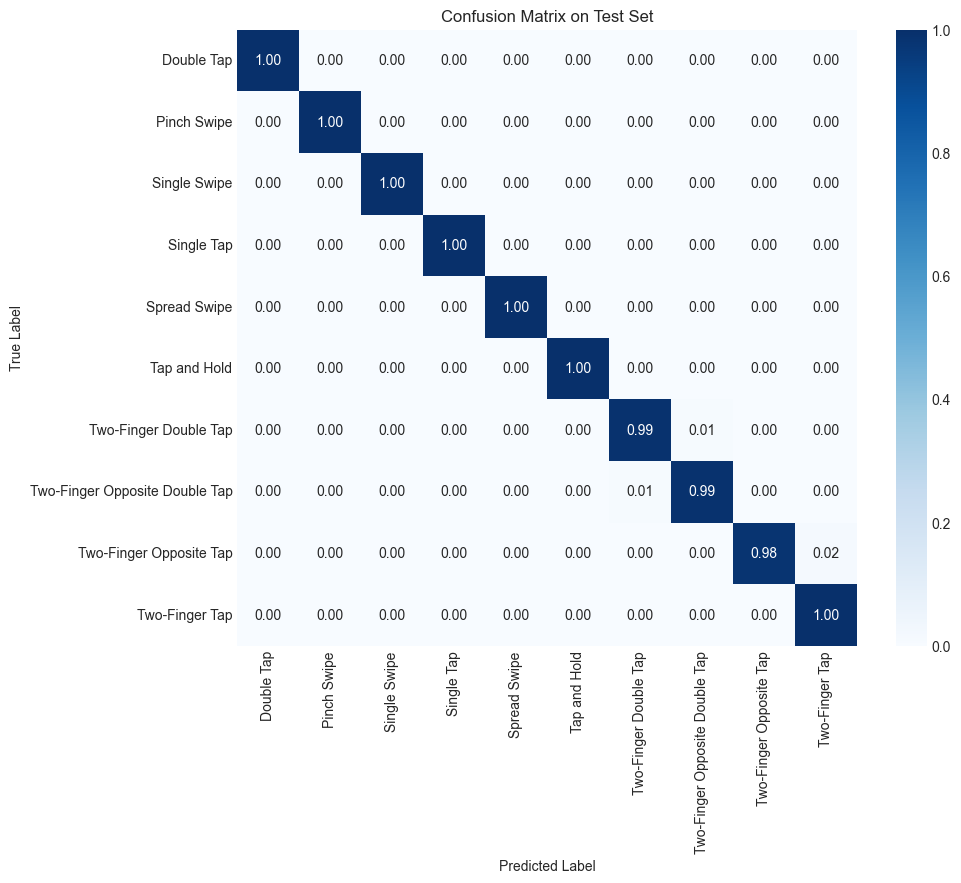

In [96]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

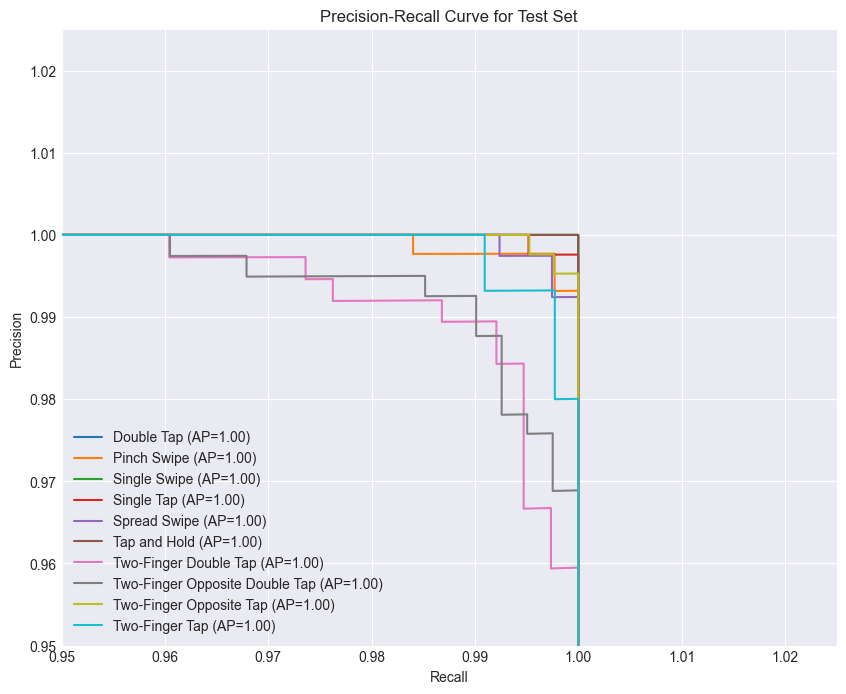

In [124]:
# Draw a precision recall curve for all classes
from sklearn.metrics import precision_recall_curve, average_precision_score
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    y_true_bin = (y_test_true == i).astype(int)
    y_scores = y_test_pred_probs[:, i]
    precision, recall, _ = precision_recall_curve(y_true_bin, y_scores)
    ap = average_precision_score(y_true_bin, y_scores)
    plt.plot(recall, precision, label=f'{le.classes_[i]} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Test Set')
plt.ylim(0.95, 1.025)
plt.xlim(0.95, 1.025)
plt.legend()
plt.show()

## Test with Szenarios

In [97]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [98]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [99]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [100]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [101]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position         0
touch_1_pressure         0
touch_1_channel          0
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            100522
dtype: int64

In [102]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Tap                     553
Two-Finger Double Tap              516
Two-Finger Opposite Double Tap     486
Double Tap                         367
Two-Finger Opposite Tap            315
Name: count, dtype: int64


In [103]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 227


In [104]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [105]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    streams[sid] = X_stream
    streams_labels[sid] = y_stream

In [106]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 227 streams from Szenarien data.


In [107]:
max_len = 70
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream, y_stream):
    did_print = 0
    T, D = X_stream.shape
    preds = []
    pred_times = []
    real_labels = []
    probas = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        window_labels = y_stream[t_start:t_end]
        if not any(label is not None for label in window_labels):
            continue

        # Check if the full window is the same gesture
        unique_labels_in_window = set(label for label in window_labels if label is not None)
        # Check that the label is fully included in the window, by check if the first and last label are none
        if (window_labels[0] is not None or window_labels[-1] is not None) and len(unique_labels_in_window) != 1:
            continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        y_window = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]

        # Get the correct label for this window (most common label in the window)
        window_labels = [label for label in y_window if label is not None]
        if len(window_labels) == 0:
            continue
        most_common_label = pd.Series(window_labels).mode()[0]
        real_labels.append(most_common_label)
        
        # --- Model Prediction Logic ---
        window_batch = window[np.newaxis, ...]
        proba = model.predict(window_batch, verbose=0)[0]

        probas.append(proba)

        # print all probabilities for debug with label
        # for cls_idx, class_label in enumerate(le.classes_):
        #     ax.text(t_start, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]) * (cls_idx + 1), 
        #             f"{class_label}: {proba[cls_idx]:.2f}", fontsize=10, verticalalignment='bottom')

        cls_idx = np.argmax(proba)
        conf = proba[cls_idx]
        label = le.classes_[cls_idx] # if conf >= threshold else "No Gesture"

        # if label != most_common_label:
        #     print(f"Mismatch at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     for cls_idx_debug, class_label in enumerate(le.classes_):
        #         print(f"  {class_label}: {proba[cls_idx_debug]:.4f}")

        #     # Draw a graph of all finger positions
        #     plt.figure(figsize=(15, 10))
        #     time_axis = np.arange(window.shape[0])
        #     for touch_num in range(2, 6):
        #         plt.scatter(
        #             time_axis, 
        #             window[:, feature_columns.index(f"dist_1_{touch_num}")], 
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #     plt.xlabel("Time Step")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Window starting at {t_start}\nPredicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     plt.legend()
        #     plt.show()
        #     return
        # else:
        #     print(f"Match at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        
        # Add text info to the plot itself
        # ax.text(t_start, ax.get_ylim()[1], f"Pred: {label} ({conf:.2f})", 
        #         fontsize=12, fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

        preds.append(label)
        pred_times.append(t_start)

        # did_print += 1
        # if did_print >= 5:
        #     break

    # plt.tight_layout()
    # plt.show()
    return np.array(preds), np.array(pred_times), np.array(real_labels), np.array(probas)


Using max_len=70, threshold=0.05 for online prediction.


In [108]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []
all_probas = []

# print streams keys
did_it = 0
for sid, X_stream in streams.items():
    did_it += 1
    y_stream = streams_labels[sid] 
    preds, pred_times, real_labels, probas = predict_stream_online(X_stream, y_stream)

    all_true.extend(real_labels)
    all_pred.extend(preds)
    all_probas.extend(probas)

    # Print y_stream for those that are not none
    # print(f"True labels for stream {sid}:")
    # for i in range(len(y_stream)):
    #     if y_stream[i] is not None:
    #         print(f"  Index {i}: {y_stream[i]}")

    # if did_it >= 1:
    #     break


In [109]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_probas = np.array(all_probas)
# Replace None with "No Gesture" in all_true
all_true = np.array([label if label is not None and label != 'No Gesture' else "Double Tap" for label in all_true])
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: ({len(unique_true_labels)}) {unique_true_labels}")
print(f"Unique predicted labels: ({len(unique_pred_labels)}) {unique_pred_labels}")

Unique true labels: (9) ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Spread Swipe' 'Tap and Hold'
 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted labels: (10) ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Single Tap' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.12      0.00      0.01       491
                   Pinch Swipe       0.13      0.45      0.20        85
                  Single Swipe       0.25      0.62      0.36       265
                    Single Tap       0.00      0.00      0.00         0
                  Spread Swipe       0.39      0.15      0.22       240
                  Tap and Hold       0.16      0.18      0.17       276
         Two-Finger Double Tap       0.04      0.03      0.03       148
Two-Finger Opposite Double Tap       0.25      0.56      0.34        75
       Two-Finger Opposite Tap       0.28      0.67      0.39        61
                Two-Finger Tap       0.13      0.04      0.06       234

                      accuracy                           0.21      1875
                     macro avg       0.17      0.27      0.18      1875
                  weighted avg       0.18      0.21      0.15 

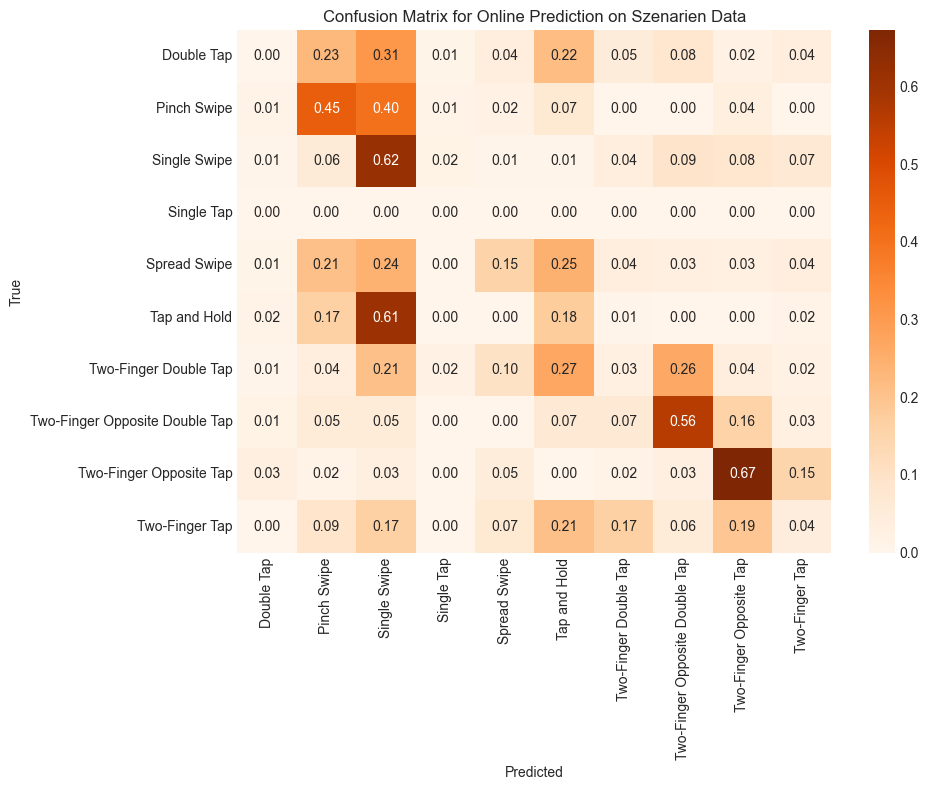

In [110]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)

used_labels = np.unique(np.concatenate([y_true_int, y_pred_int]))
used_target_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_true_int,
        y_pred_int,
        labels=used_labels,
        target_names=used_target_names
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le.classes_)))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [111]:
# Print the top-k stats
from collections import defaultdict

def top_k_classification_report(
    y_true,
    y_proba,
    k=3,
    class_names=None
):
    n_classes = y_proba.shape[1]
    top_k_preds = np.argsort(y_proba, axis=1)[:, -k:]

    support = defaultdict(int)
    tp = defaultdict(int)
    pred_count = defaultdict(int)

    for i, true_cls in enumerate(y_true):
        support[true_cls] += 1

        for pred_cls in top_k_preds[i]:
            pred_count[pred_cls] += 1
            if pred_cls == true_cls:
                tp[pred_cls] += 1

    rows = []

    for cls in range(n_classes):
        sup = support[cls]
        if sup == 0:
            precision = recall = f1 = 0.0
        else:
            precision = tp[cls] / pred_count[cls] if pred_count[cls] > 0 else 0.0
            recall = tp[cls] / sup
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0
                else 0.0
            )

        name = class_names[cls] if class_names is not None else str(cls)
        rows.append((name, precision, recall, f1, sup))

    return rows

In [112]:
top1 = top_k_classification_report(
    y_true_int,
    all_probas,
    k=1,
    class_names=le.classes_
)

top3 = top_k_classification_report(
    y_true_int,
    all_probas,
    k=3,
    class_names=le.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@3':>6s}{'R@3':>6s}{'F1@3':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@3   R@3   F1@3   Sup
Double Tap                           0.12  0.00   0.01 |   0.33  0.31   0.32   491
Pinch Swipe                          0.13  0.45   0.20 |   0.08  0.72   0.15    85
Single Swipe                         0.25  0.62   0.36 |   0.16  0.90   0.27   265
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Spread Swipe                         0.39  0.15   0.22 |   0.22  0.63   0.33   240
Tap and Hold                         0.16  0.18   0.17 |   0.27  0.75   0.40   276
Two-Finger Double Tap                0.04  0.03   0.03 |   0.13  0.26   0.17   148
Two-Finger Opposite Double Tap       0.25  0.56   0.34 |   0.11  0.73   0.19    75
Two-Finger Opposite Tap              0.28  0.67   0.39 |   0.20  0.79   0.32    61
Two-Finger Tap                       0.13  0.04   0.06 |   0.18  0.34   0.24   234


In [113]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    # ignore if the marker_label is "No Gesture" or None
    if gdf["marker_label"].iloc[0] is None or gdf["marker_label"].iloc[0] == "No Gesture":
        continue
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 145 windows from Szenarien data for group_id prediction.


In [114]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=11, max=333
Window label counts:
  Two-Finger Tap: 29
  Single Swipe: 25
  Spread Swipe: 18
  Two-Finger Double Tap: 15
  Two-Finger Opposite Double Tap: 14
  Two-Finger Opposite Tap: 13
  Tap and Hold: 13
  Double Tap: 11
  Pinch Swipe: 7


In [115]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_batch = X_window[np.newaxis, ...]  # (1, max_len, D)
    proba = model.predict(X_batch, verbose=0)[0]
    
    all_window_proba.append(proba)

    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (9) ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Spread Swipe' 'Tap and Hold'
 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted window labels: (9) ['Double Tap' 'Pinch Swipe' 'Single Swipe' 'Spread Swipe' 'Tap and Hold'
 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       1.00      0.36      0.53        11
                   Pinch Swipe       0.41      1.00      0.58         7
                  Single Swipe       0.94      0.64      0.76        25
                  Spread Swipe       0.52      0.67      0.59        18
                  Tap and Hold       1.00      0.15      0.27        13
         Two-Finger Double Tap       0.89      0.53      0.67        15
Two-Finger Opposite Double Tap       0.52      1.00      0.68        14
       Two-Finger Opposite Tap       0.40      0.92      0.56        13
                Two-Finger Tap       0.88      0.48      0.62        29

                      accuracy                           0.61       145
                     macro avg       0.73      0.64      0.58       145
                  weighted avg       0.77      0.61      0.61       145



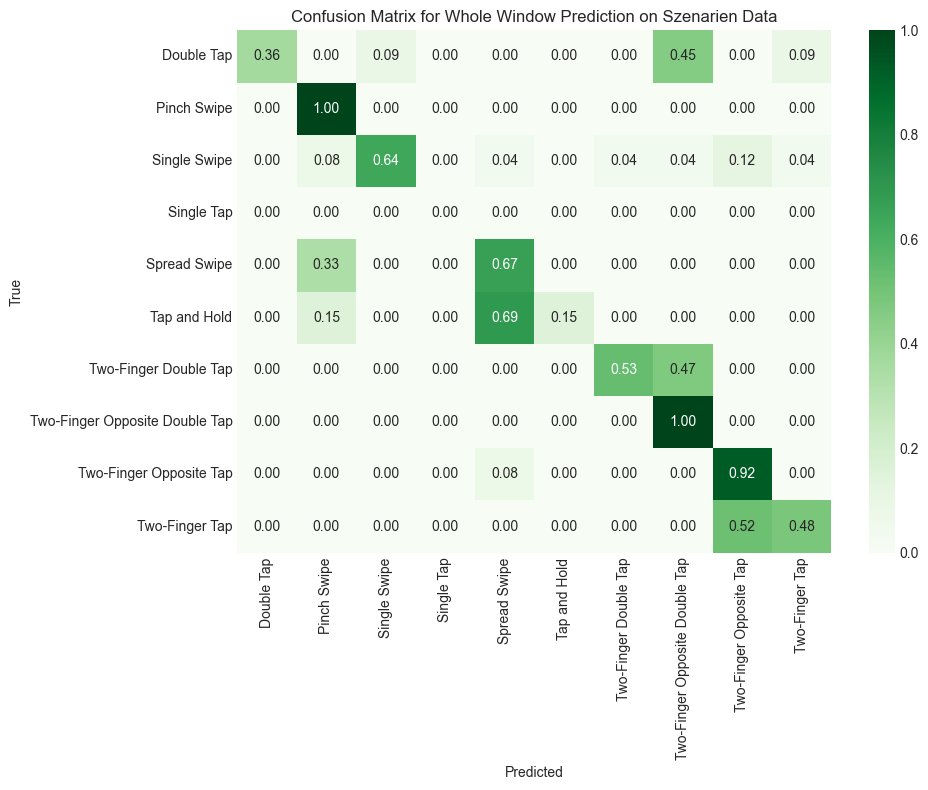

In [116]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le.transform(all_window_pred)

used_labels_window = np.unique(np.concatenate([y_window_true_int, y_window_pred_int]))
used_target_names_window = le.inverse_transform(used_labels_window)
print(
    classification_report(
        y_window_true_int,
        y_window_pred_int,
        labels=used_labels_window,
        target_names=used_target_names_window
    )
)

cm_window = confusion_matrix(y_window_true_int, y_window_pred_int, labels=range(len(le.classes_)))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()

In [117]:
top1 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=1,
    class_names=le.classes_
)

top3 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=3,
    class_names=le.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@3':>6s}{'R@3':>6s}{'F1@3':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@3   R@3   F1@3   Sup
Double Tap                           1.00  0.36   0.53 |   0.38  0.55   0.44    11
Pinch Swipe                          0.41  1.00   0.58 |   0.12  1.00   0.22     7
Single Swipe                         0.94  0.64   0.76 |   0.32  0.92   0.47    25
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Spread Swipe                         0.52  0.67   0.59 |   0.33  1.00   0.49    18
Tap and Hold                         1.00  0.15   0.27 |   0.50  0.38   0.43    13
Two-Finger Double Tap                0.89  0.53   0.67 |   0.27  0.87   0.41    15
Two-Finger Opposite Double Tap       0.52  1.00   0.68 |   0.20  1.00   0.34    14
Two-Finger Opposite Tap              0.40  0.92   0.56 |   0.26  0.92   0.40    13
Two-Finger Tap                       0.88  0.48   0.62 |   0.60  0.97   0.74    29


In [118]:
import winsound

winsound.MessageBeep()  # system default sound